# Final Project: How does the wind effect athletes performances?
### Name: Alexia Barnes, Max Ford Wilson, Jack Howard

# Introduction

The World Athletics Database provided stats for various events recorded between 1935 and 2023. The database records professional events regarding track & field competitions, noting the Competitors names, birthdates, sex, and nationalities, their rank in the event and their results score the World Athletics Database determined themselves, the marks of the performance in either distance or time, the positions held during the performance, as well as the date, venue, wind, and event type of each performance.

Since we are focused on how windspeed impacts performance, we will filter our data to only cases where windspeed was recorded during an event. Out of the 463,847 cases our CSV file began with, we have 125,286 to work with. 

For our research, we are focused on Rank, Mark, Results Score, Event, and Wind.
* **Rank**: Rank is the performance for a given Event, split by Sex.
* **Mark [meters or seconds]**: Mark is the result entry for a given Event, given either in meters or seconds.
* **Results Score**: Results Score is the World Athletics' score assigned to each performance.
* **Event**: Event is whatever event the performance being recorded was in.
* **Wind**: Wind is the windspeed during the time of the performance.

### Exploring the Data
We begin exploring the data by looking at the dataframe. Then, we further explore variables individually.

In [1]:
# Importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reading in data, splitting columns
data = pd.read_csv(
    "https://raw.githubusercontent.com/thomascamminady/world-athletics-database/main/data/data.csv",
    delimiter=";",
    parse_dates=True
)
df = pd.DataFrame(data)

#Displaying the data frame
df.head()

,Rank,Mark,Competitor,DOB,Nat,Pos,Venue,Date,Results Score,Mark [meters or seconds],Event,Wind,Sex
0,1,3:43.13,Hicham EL GUERROUJ,1974-09-14,MAR,1,"Stadio Olimpico, Roma (ITA)",1999-07-07,1292,223.1,One Mile,NaN,male
1,2,3:43.40,Noah NGENY,1978-11-02,KEN,2,"Stadio Olimpico, Roma (ITA)",1999-07-07,1288,223.4,One Mile,NaN,male
2,3,3:44.39,Noureddine MORCELI,1970-02-28,ALG,1,Rieti (ITA),1993-09-05,1275,224.3,One Mile,NaN,male
3,4,3:44.60,Hicham EL GUERROUJ,1974-09-14,MAR,1,Nice (FRA),1998-07-16,1272,224.6,One Mile,NaN,male
4,5,3:44.90,Hicham EL GUERROUJ,1974-09-14,MAR,1,Oslo (NOR),1997-07-04,1268,224.9,One Mile,NaN,male


In [2]:
# df.shape
# df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461522 entries, 0 to 461521
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Rank                      461522 non-null  int64  
 1   Mark                      461522 non-null  object 
 2   Competitor                461522 non-null  object 
 3   DOB                       455092 non-null  object 
 4   Nat                       461522 non-null  object 
 5   Pos                       458791 non-null  object 
 6   Venue                     461522 non-null  object 
 7   Date                      461522 non-null  object 
 8   Results Score             461522 non-null  int64  
 9   Mark [meters or seconds]  461522 non-null  float64
 10  Event                     461522 non-null  object 
 11  Wind                      125286 non-null  float64
 12  Sex                       461522 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory us

In [3]:
# We look to see when the first and last events included were recorded
print(f"First event: {df['Date'].min()}, Most recent event: {df['Date'].max()}")

First event: 1935-05-25, Most recent event: 2023-07-01


In [4]:
# We look at all counts of Events recorded
df.groupby('Event').size()

Event
10 Kilometres                1769
10 Kilometres Race Walk      2286
10 Miles Road                 306
100 Metres                  51858
100 Metres Hurdles           7585
1000 Metres                  1029
10000 Metres                 7978
10000 Metres Race Walk        687
110 Metres Hurdles          13970
15 Kilometres                 387
1500 Metres                 18563
20 Kilometres                 378
20 Kilometres Race Walk     13048
200 Metres                  37072
2000 Metres                   302
2000 Metres Steeplechase      936
20000 Metres Race Walk        203
30 Kilometres Race Walk       112
300 Metres                    994
3000 Metres                  5002
3000 Metres Race Walk         339
3000 Metres Steeplechase    24790
35 Kilometres Race Walk       924
400 Metres                  19056
400 Metres Hurdles          22480
5 Kilometres                 1783
5 Kilometres Race Walk        740
50 Kilometres Race Walk      1818
5000 Metres                 12920
5000 Met

In [5]:
# We look at count of athletes across sexes
df.groupby('Sex').size()

Sex
female    226677
male      234845
dtype: int64

## Cleaning the Data

In [6]:
# Removing rows without Wind data
filtered_df = df[df['Wind'].notna()].copy()

# Determining Competitor's Age at time of their event
filtered_df['Date'] = pd.to_datetime(filtered_df.Date)
filtered_df['DOB'] = pd.to_datetime(filtered_df.DOB)
filtered_df['Days'] = (filtered_df['Date'] - filtered_df['DOB'])
filtered_df['Age'] = (pd.to_timedelta(filtered_df['Days'], unit='D') / np.timedelta64(365, 'D'))

# Removing rows that were recorded before the year 2000 (range is now 2000-2023 instead of 1935-2023)
filtered_df = filtered_df[filtered_df['Date'].dt.year >= 2000]
# Narrow down rows to included ages 18-35
filtered_df = filtered_df[(filtered_df['Age'] >= 18) & (filtered_df['Age'] <= 35)]
# Only keep wind levels > -4.0
filtered_df = filtered_df[filtered_df['Wind'] >= -4.0]

# Dropping unutilized columns and renaming columns
filtered_df = filtered_df.drop(columns=['Nat', 'Venue', 'Mark [meters or seconds]', 'Days', 'Pos'])
filtered_df = filtered_df.rename(columns={'Results Score' : 'Score'})


# filtered_df.head()
filtered_df.info()
# filtered_df.groupby('Event').size()
# df.columns
# filtered_df.columns

<class 'pandas.core.frame.DataFrame'>
Index: 91483 entries, 62759 to 461521
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Rank        91483 non-null  int64         
 1   Mark        91483 non-null  object        
 2   Competitor  91483 non-null  object        
 3   DOB         91483 non-null  datetime64[ns]
 4   Date        91483 non-null  datetime64[ns]
 5   Score       91483 non-null  int64         
 6   Event       91483 non-null  object        
 7   Wind        91483 non-null  float64       
 8   Sex         91483 non-null  object        
 9   Age         91483 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(2), object(4)
memory usage: 7.7+ MB


## Histograms w/ Density Curves

We can look at various density plots for our variables to help us see the shape of our data and how it is distributed.

Text(0.5, 1.0, 'Wind Distribution Comparison of 100 Metres vs Long Jump')

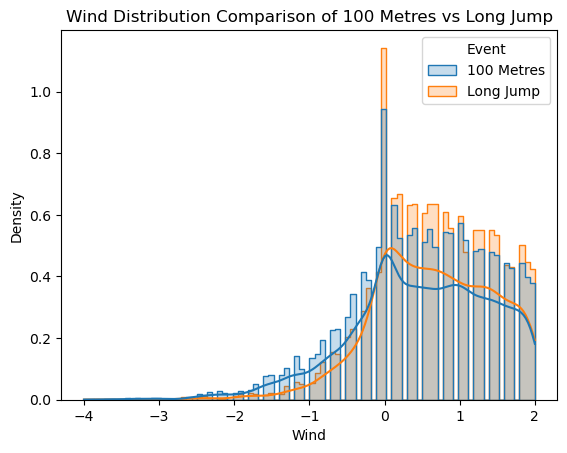

In [ ]:
# Filter our dataset further to have the 2 events we're focusing on
hist_df = filtered_df[filtered_df['Event'].isin(['100 Metres', 'Long Jump'])]

# Create a histogram/density plot to compare the wind distribution of the 2 events
sns.histplot(
    data=hist_df,
    x="Wind",
    hue="Event",
    kde=True,
    stat="density",
    element="step", # outline instead of filled bars
    common_norm=False # scale event data independently since sample sizes differ greatly
)

plt.title(label = "Wind Distribution Comparison of 100 Metres vs Long Jump")

# Very similar distributions with the most amount of records being recorded with a wind speed of abt 0.

Wind readings for both events are very concentrated around 0 and left-skewed.

Text(0.5, 1.0, 'Age Distribution Comparison of 100 Metres vs Long Jump')

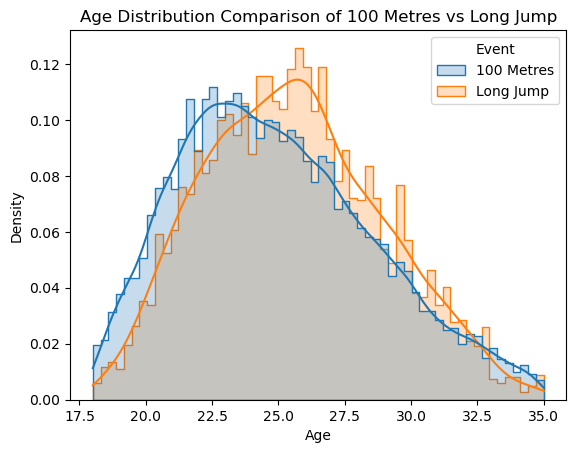

In [ ]:
# Create a histogram/density plot to compare the wind distribution of the 2 events
sns.histplot(
    data=hist_df,
    x="Age",
    hue="Event",
    kde=True,
    stat="density",
    element="step", # outline instead of filled bars
    common_norm=False # scale event data independently since sample sizes differ greatly
)

plt.title(label = "Age Distribution Comparison of 100 Metres vs Long Jump")

## Running (100 Metres) Analysis

In [ ]:
# Narrowing down events and creating a dataframe for running (100m)
running_df = filtered_df[filtered_df['Event'] == '100 Metres'].copy()

# running_df.info()

# Converting 'Mark' times to numeric instead of object dtype
running_df['Mark'] = pd.to_numeric(running_df['Mark'], errors='coerce')
running_df['Mark'].dtype
running_df[['Mark', 'Event']].sample(50)

# running_df.head()
running_df.describe()

,Rank,Mark,DOB,Date,Score,Wind,Age
count,38394.000000,38394.000000,38394,38394,38394.00000,38394.000000,38394.000000
mean,12696.955514,10.787016,1988-05-21 18:28:31.392404992,2013-04-26 05:17:02.222222336,1138.10611,0.494171,24.946439
min,1.000000,9.580000,1966-02-20 00:00:00,2000-01-15 00:00:00,1093.00000,-4.000000,18.002740
25%,6213.000000,10.220000,1982-10-06 00:00:00,2007-08-26 00:00:00,1112.00000,-0.100000,22.164384
50%,12725.000000,11.040000,1988-11-06 00:00:00,2014-05-17 00:00:00,1131.00000,0.500000,24.558904
75%,18697.000000,11.370000,1994-09-11 00:00:00,2019-02-22 00:00:00,1157.00000,1.200000,27.396575
max,25950.000000,11.500000,2005-05-02 00:00:00,2023-07-01 00:00:00,1356.00000,2.000000,35.000000
std,7373.242727,0.580023,NaN,NaN,33.36881,0.929696,3.649304


## Pairwise Scatterplot (Running)
Let's create a pairwise scatterplot to check for trends in the 100 Metres data.

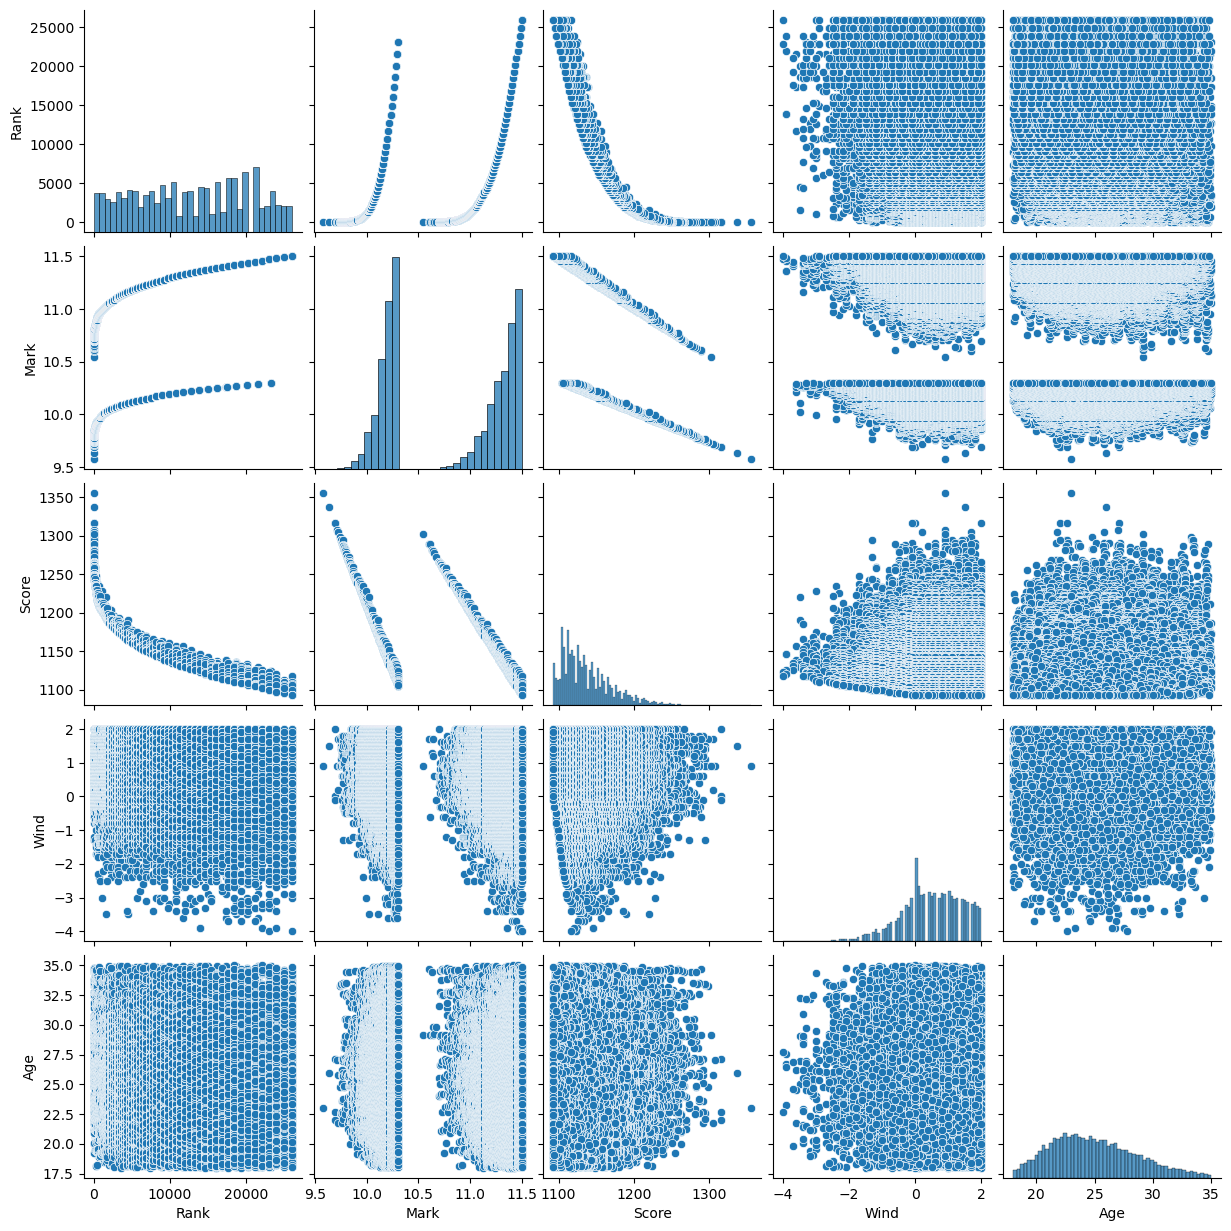

In [ ]:
sns.pairplot(running_df)

There appears to be two distinct groups for Mark with all the other variables. Perhaps there could be two groups of runners based on Sex. Let's explore that further.

## Wind VS Mark Density Curve + Scatterplot (Running)

Text(0.5, 1.0, 'Mark (seconds) Distribution for the 100 Meters')

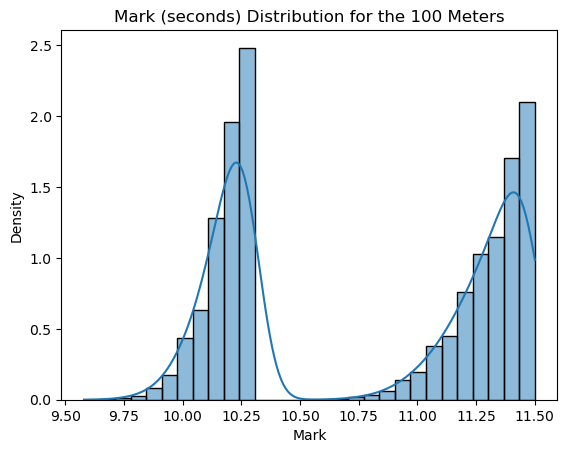

In [22]:
sns.histplot(
    data=running_df,
    x="Mark",
    kde=True,
    stat="density"
)

plt.title(label = "Mark (seconds) Distribution for the 100 Meters")

Here is the scatterplot for Wind vs Mark (seconds) for the 100M.

<Axes: xlabel='Wind', ylabel='Mark'>

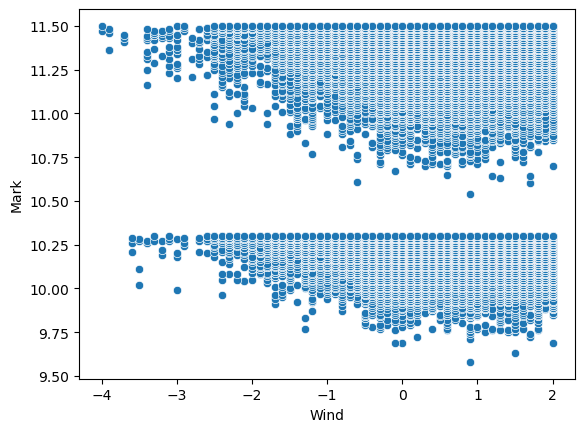

In [18]:
sns.scatterplot(data=running_df, x='Wind', y='Mark')

Now here's the same scatterplot colored by Sex.

<Axes: xlabel='Wind', ylabel='Mark'>

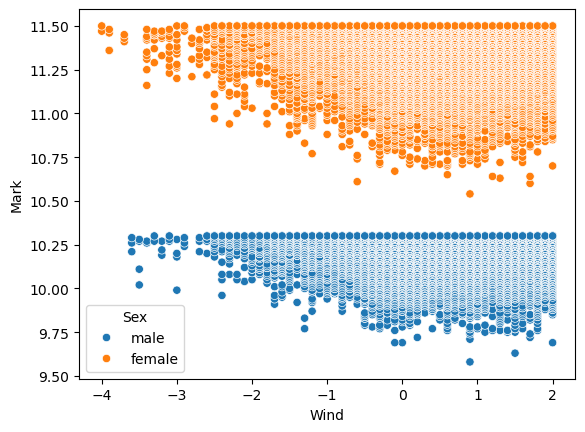

In [19]:
sns.scatterplot(data=running_df, x='Wind', y='Mark', hue='Sex')

Looks like our suspicions were correct! The two distinct groups are due to gender, which explains why there is such a harsh cutoff for running times in the data.

If we try and create a linear model on the overall 100 Meters data without separating by Sex, the real relationship between Wind and Mark could be hidden.

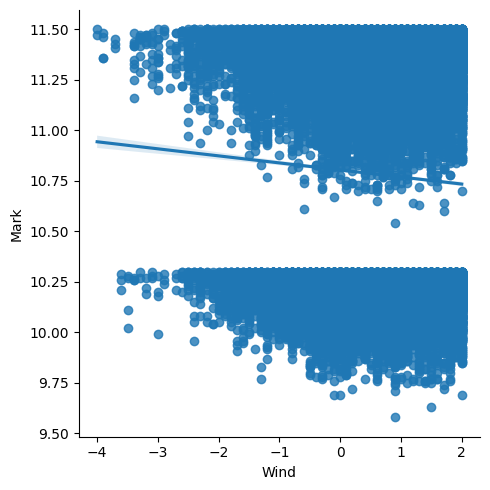

In [ ]:
sns.lmplot(x='Wind', y='Mark', data=running_df)

In [24]:
# Narrowing down events and creating a dataframe for jumping (long jump)
jumping_df = filtered_df[filtered_df['Event'] == 'Long Jump'].copy()

# Converting 'Mark' times to numeric instead of object dtype
jumping_df['Mark'] = pd.to_numeric(jumping_df['Mark'], errors='coerce')
jumping_df['Mark'].dtype

# throwing_df.head()
# throwing_df.info()
jumping_df.describe()

,Rank,Mark,DOB,Date,Score,Wind,Age
count,5019.000000,5019.000000,5019,5019,5019.000000,5019.000000,5019.000000
mean,2803.039251,7.824517,1986-01-21 04:26:32.349073536,2011-08-08 21:44:17.501494272,1171.884638,0.648795,25.563618
min,9.000000,6.750000,1965-09-03 00:00:00,2000-01-15 00:00:00,1138.000000,-3.800000,18.008219
25%,1297.000000,8.000000,1979-10-01 00:00:00,2006-04-05 00:00:00,1151.000000,0.100000,23.036986
50%,2219.000000,8.060000,1985-10-20 00:00:00,2011-06-25 00:00:00,1167.000000,0.600000,25.421918
75%,4275.000000,8.160000,1991-09-10 00:00:00,2017-06-16 00:00:00,1186.000000,1.300000,27.843836
max,6134.000000,8.740000,2005-02-07 00:00:00,2023-07-01 00:00:00,1311.000000,2.000000,35.000000
std,1801.037726,0.556949,NaN,NaN,26.449242,0.801212,3.358444


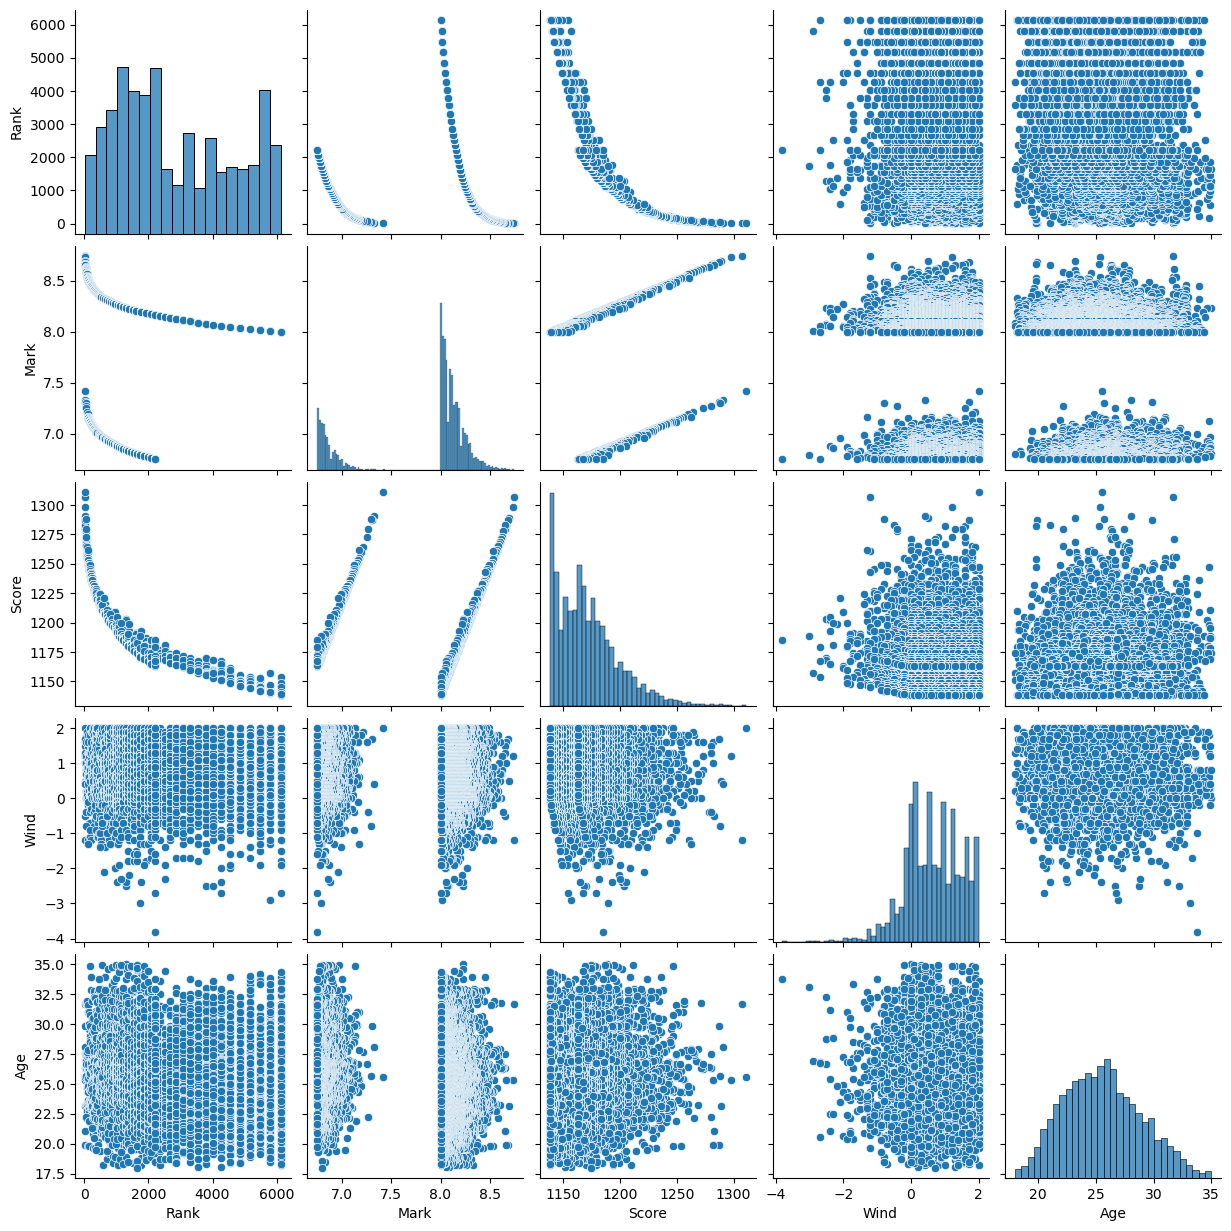

In [25]:
sns.pairplot(jumping_df)

## Wind VS Mark Density Curve + Scatterplot (Jumping)

<Axes: xlabel='Mark', ylabel='Density'>

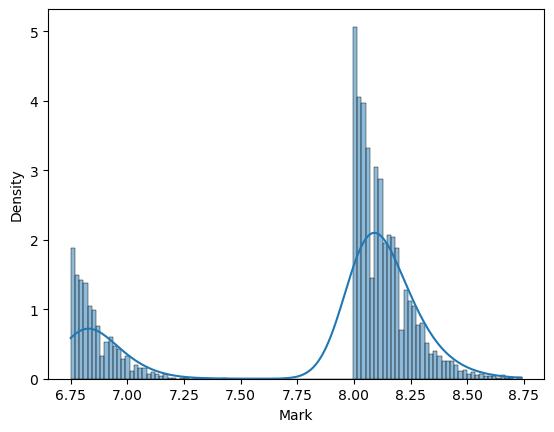

In [ ]:
sns.histplot(
    data=jumping_df,
    x="Mark",
    kde=True,
    stat="density"
)

In [ ]:
sns.scatterplot(data=jumping_df, x='Wind', y='Mark')

<Axes: xlabel='Wind', ylabel='Mark'>

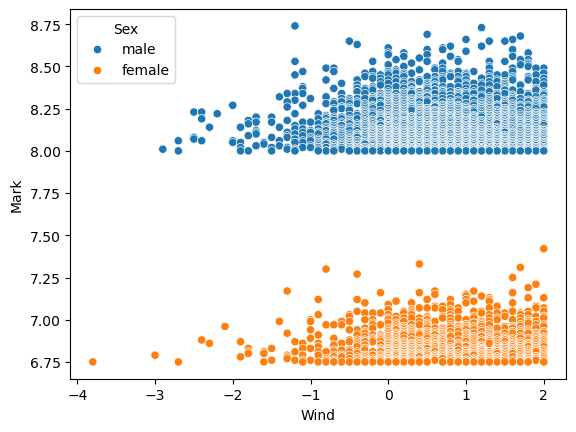

In [28]:
sns.scatterplot(data=jumping_df, x='Wind', y='Mark', hue='Sex')

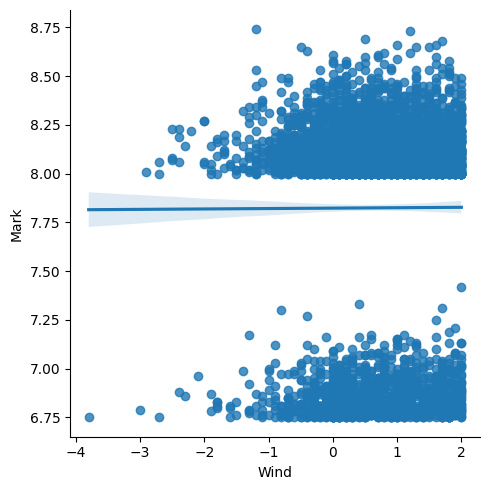

In [21]:
sns.lmplot(x='Wind', y='Mark', data=jumping_df)

## Machine Learning

Now we will apply ML methods to better understand the relationship between wind speed and perfomance. We use **K-Means Clustering** to find   tiers within the  data, and then fit **separate linear regression models** for each distinct group. Doing this we can capture the differnt relationships that may exist across many different skill levels to avoid generalizing the data. 

### K-Means Clustering (100 Metres)

Based on the scatter plot of Wind vs. Mark, there seem to be two distinct groups. Using K-means clustering we can separate these groups and model them independently. 

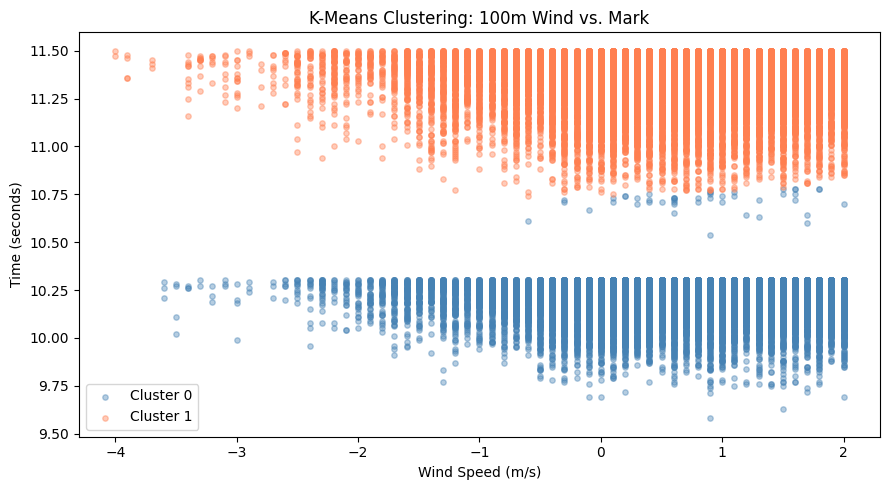

Cluster
1    20339
0    18055
Name: Count, dtype: int64


In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

kmeans_df = running_df[["Wind", "Mark"]].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(kmeans_df)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_df["Cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(9, 5))
for cluster_id, color, label in zip([0, 1], ["steelblue", "coral"], ["Cluster 0", "Cluster 1"]):
    subset = kmeans_df[kmeans_df["Cluster"] == cluster_id]
    plt.scatter(subset["Wind"], subset["Mark"], alpha=0.4, s=15, color=color, label=label)

plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Time (seconds)")
plt.title("K-Means Clustering: 100m Wind vs. Mark")
plt.legend()
plt.tight_layout()
plt.show()

# Cluster sizes
print(kmeans_df["Cluster"].value_counts().rename("Count"))

The clustering reveals that the two groups largely correspond to gender — male athletes cluster around faster times (~10s) and female athletes around slower times (~11s). Rather than modeling by cluster, we therefore split by gender directly, which gives a more interpretable and meaningful separation for regression.

### Linear Regression by Gender (100 Metres)

Since male and female athletes have significantly different baseline 100m times, we fit a separate linear regression model for each gender. This lets us directly compare how wind speed affects performance for male vs. female athletes.

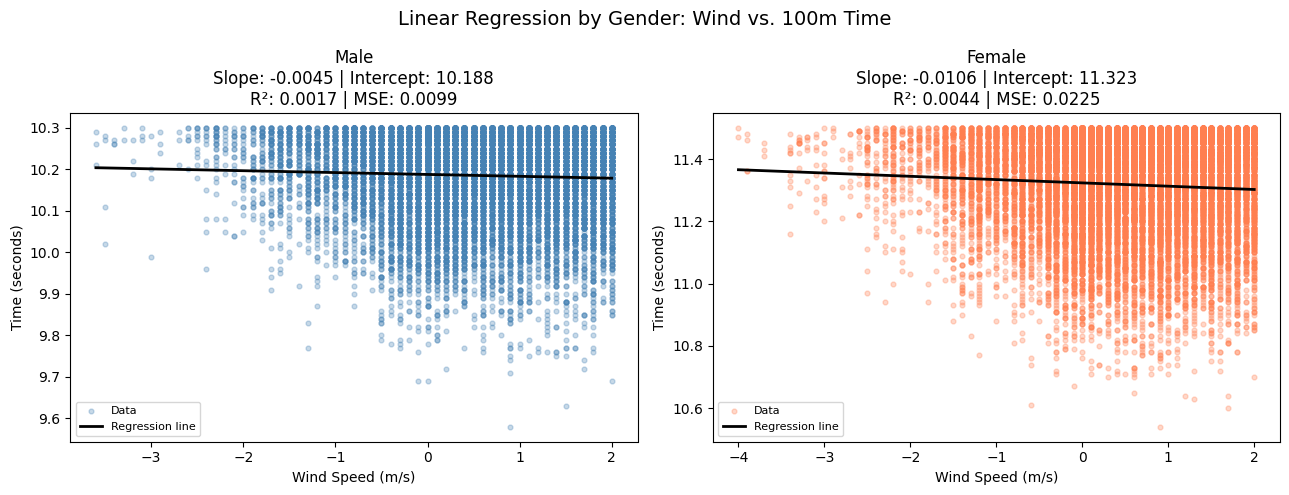

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {"male": "steelblue", "female": "coral"}
gender_labels = {"male": "Male", "female": "Female"}

gender_models = {}

for col, gender in enumerate(["male", "female"]):
    subset = running_df[running_df["Sex"] == gender].dropna(subset=["Wind", "Mark"]).copy()

    X = subset[["Wind"]]
    y = subset["Mark"]
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    gender_models[gender] = model

    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    ax = axes[col]
    ax.scatter(subset["Wind"], subset["Mark"], alpha=0.3, s=12,
               color=colors[gender], label="Data")

    wind_range = pd.DataFrame(
        np.linspace(subset["Wind"].min(), subset["Wind"].max(), 200),
        columns=["Wind"]
    )
    ax.plot(wind_range["Wind"], model.predict(wind_range),
            color="black", linewidth=2, label="Regression line")

    ax.set_title(
        f"{gender_labels[gender]}\n"
        f"Slope: {model.coef_[0]:.4f} | Intercept: {model.intercept_:.3f}\n"
        f"R²: {r2:.4f} | MSE: {mse:.4f}"
    )
    ax.set_xlabel("Wind Speed (m/s)")
    ax.set_ylabel("Time (seconds)")
    ax.legend(fontsize=8)

plt.suptitle("Linear Regression by Gender: Wind vs. 100m Time", fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
# Summary table
rows = []
for gender in ["male", "female"]:
    subset = running_df[running_df["Sex"] == gender].dropna(subset=["Wind", "Mark"]).copy()
    model = LinearRegression()
    model.fit(subset[["Wind"]], subset["Mark"])
    y_pred = model.predict(subset[["Wind"]])
    rows.append({
        "Gender": gender.capitalize(),
        "Slope": round(model.coef_[0], 4),
        "Intercept": round(model.intercept_, 4),
        "R2": round(r2_score(subset["Mark"], y_pred), 4),
        "MSE": round(mean_squared_error(subset["Mark"], y_pred), 4),
        "N": len(subset)
    })

print(pd.DataFrame(rows).to_string(index=False))

Gender   Slope  Intercept     R2    MSE     N
  Male -0.0045    10.1878 0.0017 0.0099 18009
Female -0.0106    11.3233 0.0044 0.0225 20385
